# Equation of Motion

Consider a one-dimensional chain of identical masses with displacement of mass $n$ denoted by $u_n(t)$ and mass $m$. Spring $n$ connects mass $n-1$ to mass $n$, so its elongation is

$$
\Delta_n = u_n - u_{n-1}.
$$

The nonlinear force in spring $n$ is modeled as

$$
F_n(\Delta_n)=k_n\Delta_n+\alpha_n\Delta_n^3,
$$

where $k_n$ is the linear stiffness. A positive nonlinear coefficient, $\alpha_n>0$, gives a stiffening spring, while a negative coefficient, $\alpha_n<0$, gives a softening spring.

For nearest-neighbor interactions, the equation of motion for mass $n$ is

$$
m\ddot{u}_n = F_{n+1}(u_{n+1}-u_n)-F_n(u_n-u_{n-1}).
$$

Substituting the cubic nonlinear spring law gives

$$
m\ddot{u}_n =
k_{n+1}(u_{n+1}-u_n)
+\alpha_{n+1}(u_{n+1}-u_n)^3
-k_n(u_n-u_{n-1})
-\alpha_n(u_n-u_{n-1})^3.
$$

If all linear stiffnesses are equal, $k_n=k$, this simplifies to

$$
m\ddot{u}_n =
k(u_{n+1}-2u_n+u_{n-1})
+\alpha_{n+1}(u_{n+1}-u_n)^3
-\alpha_n(u_n-u_{n-1})^3.
$$

For an alternating stiffening/softening chain, use

$$
\alpha_n =
\begin{cases}
+\alpha_s, & \text{stiffening spring},\\
-\alpha_f, & \text{softening spring},
\end{cases}
$$

with $\alpha_s>0$ and $\alpha_f>0$.


# Numerical implementation

The simulation below uses a finite chain with fixed end supports, so the end displacements are held at zero. For $N$ moving masses there are $N+1$ springs, and the nonlinear coefficients alternate between stiffening and softening springs.


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import chirp
import os, uuid
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp



plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.grid": True,
})
class LazyNPZ:
    """Load a single array from a compressed .npz archive only when requested."""

    def __init__(self, path, **metadata):
        self.path = str(path)
        self._metadata = dict(metadata)
        self._cache = {}
        with np.load(self.path, allow_pickle=True) as data:
            self._keys = tuple(data.files)

    @property
    def keys(self):
        return self._keys

    def __contains__(self, key):
        return key in self._metadata or key in self._keys

    def __getitem__(self, key):
        if key in self._metadata:
            return self._metadata[key]
        if key not in self._keys:
            raise KeyError(key)
        if key not in self._cache:
            with np.load(self.path, allow_pickle=True) as data:
                self._cache[key] = data[key]
        return self._cache[key]

    def get(self, key, default=None):
        return self[key] if key in self else default

    def load(self, *keys):
        if len(keys) == 1:
            return self[keys[0]]
        with np.load(self.path, allow_pickle=True) as data:
            return {key: data[key] for key in keys}

In [13]:
# Chain, forcing, and integration parameters
N = 512
m = 1.0
k = 1.0
c_dashpot = 0.00001
alpha_hard = 0.08/3
alpha_soft = -0.08/3

forced_mass = 1
force_amplitude = 0.00
force_frequency = 1.0
force_phase = 0.0
gamma = 0.08/4
history_mass_indices = [0, N // 4, forced_mass, 3 * N // 4, N - 1]
history_mass_indices = sorted(set(history_mass_indices))


n_periods_total = 500
n_periods_keep = 100
points_per_period = 100
dt = 1/(force_frequency/2/np.pi)/points_per_period
t_final = n_periods_total*points_per_period*dt

# Fixed boundaries use N + 1 springs: wall--mass--...--mass--wall.
spring_count = N + 1
k_springs = k * np.where(np.arange(spring_count) % 2 == 0, 1 - gamma, 1 + gamma)
alpha_springs = np.where(np.arange(spring_count) % 2 == 0, alpha_hard, alpha_soft)

# Localized initial condition.
u0 = np.zeros(N)
v0 = np.zeros(N)
v0[1] = 0.0001

y0 = np.concatenate([u0, v0])

# Linearized matrix form for eigenvalue/vector analysis about the zero-displacement equilibrium.
# Undamped, unforced form: M u_ddot + K u = 0.
# The nonlinear terms are omitted here because modal analysis is done on the linearized system.
from scipy.linalg import eigh

M = m * np.eye(N)
K = np.zeros((N, N))

for i in range(N):
    k_left = k_springs[i]
    k_right = k_springs[i + 1]
    K[i, i] = k_left + k_right
    if i > 0:
        K[i, i - 1] = -k_left
    if i < N - 1:
        K[i, i + 1] = -k_right

# Generalized eigenproblem: K phi = omega^2 M phi
omega2, modes = eigh( K, M)
omega_n = np.sqrt(np.clip(omega2, 0.0, None))

print(f"Assembled M and K for N={N} moving masses with fixed end supports.")
print(f"First five natural frequencies (rad/s): {omega_n[:5]}")
print("Modes are stored column-wise in `modes`; eigenvalues satisfy K phi = omega^2 M phi.")

def spring_extensions(u):
    """Return Delta_n = u_n - u_{n-1} for fixed end supports."""
    u_with_boundaries = np.concatenate(([0.0], u, [0.0]))
    return np.diff(u_with_boundaries)


def spring_forces(u):
    delta = spring_extensions(u)
    return k_springs * delta + alpha_springs * delta**3


def external_force(t ):
    force = np.zeros(N)
    force[forced_mass] = force_amplitude * np.sin(force_frequency * t )
    return force


def damping_force(v):
    delta = spring_extensions(v)
    return c_dashpot * delta


def acceleration(t, u, v, external_force = external_force):
    damping = damping_force(v)
    forces = spring_forces(u)
    return (forces[1:] - forces[:-1] + damping[1:] - damping[:-1] + external_force(t)) / m


def rhs(t, y):
    u = y[:N]
    v = y[N:]
    return np.concatenate([v, acceleration(t, u, v)])


def make_rhs(external_force = external_force):
    def rhs_local(t, y):
        u = y[:N]
        v = y[N:]
        a = acceleration(t, u, v, external_force)
        return np.concatenate([v, a])
    return rhs_local


def stroboscopic_sample(t, response, points_per_period, n_periods_keep):
    response = np.asarray(response)
    strobe_indices = np.arange(0, len(t), points_per_period)
    if response.ndim == 1:
        response_strobe = response[strobe_indices]
    else:
        response_strobe = response[..., strobe_indices]
    return {
        "t_strobe": t[strobe_indices][-n_periods_keep:],
        "response_poincare": response_strobe[..., -n_periods_keep:],
    }


def simulate_chain(
    t_eval,
    external_force=external_force,
    y0=y0,
    method="RK45",
    rtol=1e-9,
    atol=1e-10,
):
    sol = solve_ivp(
        make_rhs(external_force),
        t_span=(float(t_eval[0]), float(t_eval[-1])),
        y0=y0,
        method=method,
        t_eval=t_eval,
        rtol=rtol,
        atol=atol,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    y = sol.y.T
    u = y[:, :N]
    v = y[:, N:]
    return {
        "t": sol.t,
        "y": y,
        "u": u,
        "v": v,
    }


def total_energy(u, v):
    delta = np.apply_along_axis(spring_extensions, 1, u)
    kinetic = 0.5 * m * np.sum(v**2, axis=1)
    potential = np.sum(0.5 * k_springs * delta**2 + 0.25 * alpha_springs * delta**4, axis=1)
    return kinetic + potential

Assembled M and K for N=512 moving masses with fixed end supports.
First five natural frequencies (rad/s): [0.00612249 0.01224492 0.01836724 0.02448938 0.0306113 ]
Modes are stored column-wise in `modes`; eigenvalues satisfy K phi = omega^2 M phi.


In [14]:
omega_n.max()

np.float64(1.9999906287598563)

In [15]:
# # Plot a few mode shapes from the linearized eigenvectors.
# # Each mode is normalized independently so the shape is easy to compare across modes.
# num_modes_to_plot = 6
# mode_indices = list(range(400,410))

# x = np.arange(N)
# fig, axs = plt.subplots(len(mode_indices), 1, figsize=(9, 1.8 * len(mode_indices)), sharex=True)

# if len(mode_indices) == 1:
#     axs = [axs]

# for ax, mode_idx in zip(axs, mode_indices):
#     mode_shape = modes[:, mode_idx].real.copy()
#     max_amp = np.max(np.abs(mode_shape))
#     if max_amp > 0:
#         mode_shape /= max_amp
#     if mode_shape[np.argmax(np.abs(mode_shape))] < 0:
#         mode_shape *= -1
#     ax.plot(x, mode_shape,'.-', lw=1.5)
#     ax.axhline(0.0, color="k", lw=0.7, alpha=0.5)
#     ax.set_ylabel(f"mode {mode_idx + 1}\n$\phi$")
#     ax.set_title(f"$\omega_{mode_idx + 1} = {omega_n[mode_idx]:.4f}$ rad/s")

# axs[-1].set_xlabel("mass index")
# fig.suptitle("First few mode shapes", y=0.995)
# fig.tight_layout()
# plt.show()


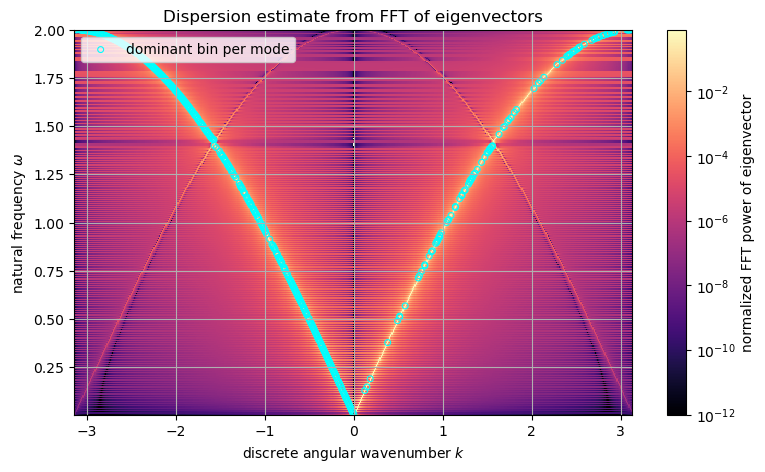

In [16]:
# Dispersion analysis from the eigenvectors.
# Each eigenvector can contain multiple wavenumber components, so we keep the full FFT power map
# instead of collapsing each mode to a single peak.
from matplotlib.colors import LogNorm

# FFT along the spatial coordinate for each mode shape.
mode_fft = np.fft.fftshift(np.fft.fft(modes, axis=0), axes=0)
mode_power = np.abs(mode_fft) ** 2
mode_power /= np.sum(mode_power, axis=0, keepdims=True) + 1e-15

# Discrete angular wavenumber bins for unit lattice spacing.
k_vals_eig = 2.0 * np.pi * np.fft.fftshift(np.fft.fftfreq(N, d=1.0))

fig, ax = plt.subplots(figsize=(9, 5))
positive_power = mode_power[mode_power > 0]
norm = LogNorm(vmin=max(positive_power.min(), 1e-12), vmax=mode_power.max())
pcm = ax.pcolormesh(k_vals_eig, omega_n, mode_power.T, shading="auto", cmap="magma", norm=norm)
fig.colorbar(pcm, ax=ax, label="normalized FFT power of eigenvector")

# Mark the dominant wavenumber bin for each eigenvector without discarding the rest of the spectrum.
dominant_k_idx = np.argmax(mode_power, axis=0)
ax.scatter(
    k_vals_eig[dominant_k_idx],
    omega_n,
    s=18,
    facecolors="none",
    edgecolors="cyan",
    linewidths=0.8,
    label="dominant bin per mode",
)

ax.set_xlabel("discrete angular wavenumber $k$")
ax.set_ylabel("natural frequency $\omega$")
ax.set_title("Dispersion estimate from FFT of eigenvectors")
ax.set_xlim(k_vals_eig[0], k_vals_eig[-1])
ax.legend(loc="upper left")
plt.show()


In [17]:
def spring_extensions(u):
    """Return Delta_n = u_n - u_{n-1} for fixed end supports."""
    u_with_boundaries = np.concatenate(([0.0], u, [0.0]))
    return np.diff(u_with_boundaries)


def spring_forces(u):
    delta = spring_extensions(u)
    return k_springs * delta + alpha_springs * delta**3


def external_force(t ):
    force = np.zeros(N)
    force[forced_mass] = force_amplitude * np.sin(force_frequency * t )
    return force


def damping_force(v):
    delta = spring_extensions(v)
    return c_dashpot * delta


def acceleration(t, u, v, external_force = external_force):
    damping = damping_force(v)
    forces = spring_forces(u)
    return (forces[1:] - forces[:-1] + damping[1:] - damping[:-1] + external_force(t)) / m


def rhs(t, y):
    u = y[:N]
    v = y[N:]
    return np.concatenate([v, acceleration(t, u, v)])


def make_rhs(external_force = external_force):
    def rhs_local(t, y):
        u = y[:N]
        v = y[N:]
        a = acceleration(t, u, v, external_force)
        return np.concatenate([v, a])
    return rhs_local


def stroboscopic_sample(t, response, points_per_period, n_periods_keep):
    response = np.asarray(response)
    strobe_indices = np.arange(0, len(t), points_per_period)
    if response.ndim == 1:
        response_strobe = response[strobe_indices]
    else:
        response_strobe = response[..., strobe_indices]
    return {
        "t_strobe": t[strobe_indices][-n_periods_keep:],
        "response_poincare": response_strobe[..., -n_periods_keep:],
    }


def simulate_chain(
    t_eval,
    external_force=external_force,
    y0=y0,
    method="RK45",
    rtol=1e-9,
    atol=1e-10,
):
    sol = solve_ivp(
        make_rhs(external_force),
        t_span=(float(t_eval[0]), float(t_eval[-1])),
        y0=y0,
        method=method,
        t_eval=t_eval,
        rtol=rtol,
        atol=atol,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    y = sol.y.T
    u = y[:, :N]
    v = y[:, N:]
    return {
        "t": sol.t,
        "y": y,
        "u": u,
        "v": v,
    }


def total_energy(u, v):
    delta = np.apply_along_axis(spring_extensions, 1, u)
    kinetic = 0.5 * m * np.sum(v**2, axis=1)
    potential = np.sum(0.5 * k_springs * delta**2 + 0.25 * alpha_springs * delta**4, axis=1)
    return kinetic + potential

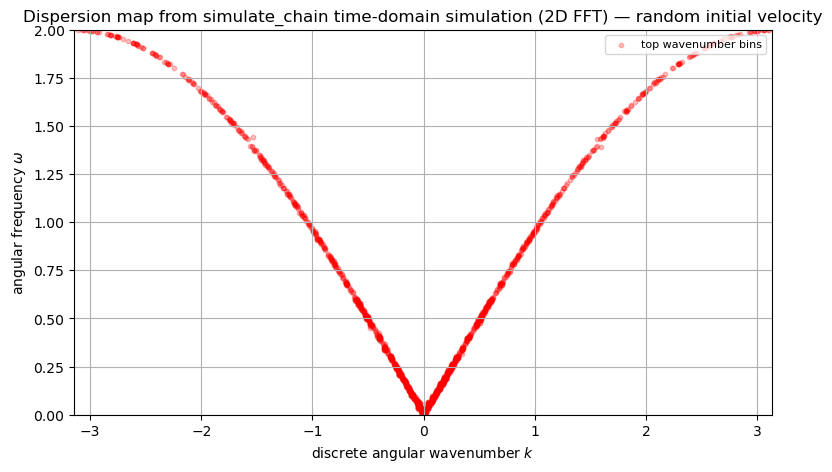

In [18]:
# Time-domain dispersion analysis using simulate_chain and a 2D FFT.
# This follows the earlier workflow: run the chain in time, then map the displacement field into (k, omega).
from matplotlib.colors import LogNorm
def filter_significant_omega_from_power(power, omega_vals, relative_threshold=1e-4, min_keep=5):
    power = np.asarray(power)
    omega_vals = np.asarray(omega_vals)

    if power.ndim == 1:
        freq_power = power
        power_matrix = None
    elif power.ndim == 2:
        freq_power = np.sum(power, axis=1)
        power_matrix = power
    else:
        raise ValueError("power must be either a 1D omega-strength vector or a 2D array with shape (n_omega, n_k)")

    if omega_vals.shape[0] != freq_power.shape[0]:
        raise ValueError("omega_vals must have the same length as the omega axis of power")

    if freq_power.size == 0:
        freq_mask = np.array([], dtype=bool)
    else:
        freq_mask = freq_power > np.max(freq_power) * relative_threshold
        if freq_mask.sum() < min_keep:
            strongest = np.argsort(freq_power)[-min(min_keep, freq_power.size):]
            freq_mask = np.zeros_like(freq_power, dtype=bool)
            freq_mask[strongest] = True

    if power_matrix is None:
        power_masked = freq_power[freq_mask]
    else:
        power_masked = power_matrix[freq_mask, :]
    omega_vals_masked = omega_vals[freq_mask]
    return power_masked, omega_vals_masked, freq_mask, freq_power


fft_periods = 1200
fft_points_per_period = 20
omega_ref = np.sqrt(2 * k / m)
fft_dt = 2.0 * np.pi / omega_ref / fft_points_per_period
fft_t_final = fft_periods * 2.0 * np.pi / omega_ref
fft_t_eval = np.arange(0.0, fft_t_final + fft_dt, fft_dt)

# Localized broadband initial condition to excite multiple spatial and temporal components.
u0_td = np.zeros(N)
# Use a reproducible random initial velocity (small amplitude broadband excitation).
rng = np.random.default_rng(42)
v0_td = 0.1 * rng.standard_normal(N)

y0_td = np.concatenate([u0_td, v0_td])

td_run = simulate_chain(
    external_force=lambda t: np.zeros(N),
    y0=y0_td,
    t_eval=fft_t_eval,
    rtol=1e-8,
    atol=1e-9,
)

u_td = td_run["u"]
t_td = td_run["t"]

# Remove the spatial mean and taper both directions to limit spectral leakage.
u_td = u_td - np.mean(u_td, axis=0, keepdims=True)
# Frequency spectrum along time, then wavenumber spectrum along space.
u_omega = np.fft.rfft(u_td, axis=0)
u_k_omega = np.fft.fftshift(np.fft.fft(u_omega, axis=1), axes=1)
power = np.abs(u_k_omega) ** 2
omega_vals = 2.0 * np.pi * np.fft.rfftfreq(len(t_td), d=fft_dt)
k_vals = 2.0 * np.pi * np.fft.fftshift(np.fft.fftfreq(N, d=1.0))

power_masked, omega_vals_masked, freq_mask, freq_power = filter_significant_omega_from_power(
    power,
    omega_vals,
    relative_threshold=1e-4,
    min_keep=5,
)
top_k_idx = np.argsort(power_masked, axis=1)[:, -3:]

fig, ax = plt.subplots(figsize=(9, 5))
norm = LogNorm(vmin=max(power_masked[power_masked > 0].min(), 1e-12), vmax=1.0)
for rank in range(top_k_idx.shape[1]):
    ax.scatter(
        k_vals[top_k_idx[:, rank]],
        omega_vals_masked,
        s=10,
        alpha=0.25,
        c="red",
        label="top wavenumber bins" if rank == 0 else None,
    )

ax.set_xlabel("discrete angular wavenumber $k$")
ax.set_ylabel("angular frequency $\\omega$")
ax.set_title("Dispersion map from simulate_chain time-domain simulation (2D FFT) — random initial velocity")
ax.set_xlim(k_vals[0], k_vals[-1])
ax.set_ylim(0, 2)
ax.legend(loc="upper right", fontsize=8)
plt.show()


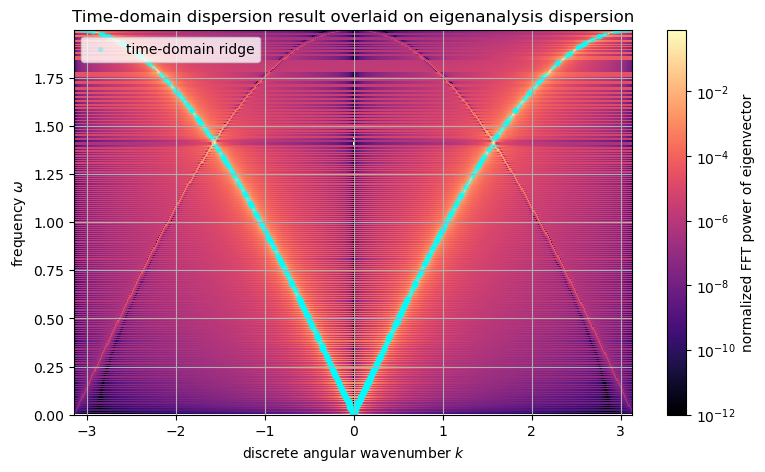

In [19]:
# Overlay the time-domain dispersion result on the eigenanalysis dispersion background.
# This reuses the already computed eigenvector FFT map and the filtered time-domain power map.
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(9, 5))
positive_power = mode_power[mode_power > 0]
norm = LogNorm(vmin=max(positive_power.min(), 1e-12), vmax=mode_power.max())
pcm = ax.pcolormesh(k_vals_eig, omega_n, mode_power.T, shading="auto", cmap="magma", norm=norm)
fig.colorbar(pcm, ax=ax, label="normalized FFT power of eigenvector")

time_top_k_idx = np.argsort(power_masked, axis=1)[:, -3:]

for rank in range(time_top_k_idx.shape[1]):
    ax.scatter(
        k_vals[time_top_k_idx[:, rank]],
        omega_vals_masked,
        s=14,
        alpha=0.35,
        c="cyan",
        edgecolors="none",
        label="time-domain ridge" if rank == 0 else None,
    )

ax.set_xlabel("discrete angular wavenumber $k$")
ax.set_ylabel("frequency $\omega$")
ax.set_title("Time-domain dispersion result overlaid on eigenanalysis dispersion")
ax.set_xlim(k_vals[0], k_vals[-1])
ax.set_ylim(0, np.max(omega_n))
ax.legend(loc="upper left")
plt.show()


In [21]:
# Compare dispersion ridges for multiple initial velocity levels.
# Each case uses the same spatial velocity profile, scaled by a different amplitude.
from joblib import Parallel, delayed
from matplotlib.colors import Normalize
import os

velocity_levels = np.array([0.05, 0.1, 0.25, 0.5, 1.0])

# Use a shorter window than the single-case study so the multi-level sweep stays practical.
fft_periods = 1200
fft_points_per_period = 20
omega_ref = np.sqrt(2 * k / m)
fft_dt = 2.0 * np.pi / omega_ref / fft_points_per_period
fft_t_final = fft_periods * 2.0 * np.pi / omega_ref
fft_t_eval = np.arange(0.0, fft_t_final + fft_dt, fft_dt)

def simulate_velocity_case(velocity_level):
    rng = np.random.default_rng(42)
    v0_td = velocity_level * rng.standard_normal(N)
    u0_td = np.zeros(N)
    y0_td = np.concatenate([u0_td, v0_td])
    td_run = simulate_chain(
        external_force=lambda t: np.zeros(N),
        y0=y0_td,
        t_eval=fft_t_eval,
        rtol=1e-8,
        atol=1e-9,
    )

    u_td = td_run["u"]
    t_td = td_run["t"]
    u_td = u_td - np.mean(u_td, axis=0, keepdims=True)
    # Frequency spectrum along time, then wavenumber spectrum along space.
    u_omega = np.fft.rfft(u_td, axis=0)
    u_k_omega = np.fft.fftshift(np.fft.fft(u_omega, axis=1), axes=1)
    power = np.abs(u_k_omega) ** 2
    omega_vals = 2.0 * np.pi * np.fft.rfftfreq(len(t_td), d=fft_dt)
    k_vals = 2.0 * np.pi * np.fft.fftshift(np.fft.fftfreq(N, d=1.0))

    power_masked, omega_vals_masked, freq_mask, freq_power = filter_significant_omega_from_power(
        power,
        omega_vals,
        relative_threshold=1e-4,
        min_keep=5,
    )
    top_k_idx = np.argsort(power_masked, axis=1)[:, -3:]

    # norm = LogNorm(vmin=max(power_masked[power_masked > 0].min(), 1e-12), vmax=1.0)
    return {
        "velocity_level": float(velocity_level),
        # "omega_vals": omega_vals,
        "omega_vals_masked": omega_vals_masked,
        # 'norm': norm,
        "k_vals": k_vals,
        "top_k_idx": top_k_idx
    }

n_workers = min(len(velocity_levels), max(1, os.cpu_count() or 1), 30)
ridge_cases = Parallel(n_jobs=n_workers, verbose=12)(
    delayed(simulate_velocity_case)(velocity_level) for velocity_level in velocity_levels
)


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   1 tasks      | elapsed:   28.8s
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:   31.4s remaining:   47.1s
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:   35.5s remaining:   23.6s
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:   40.0s finished


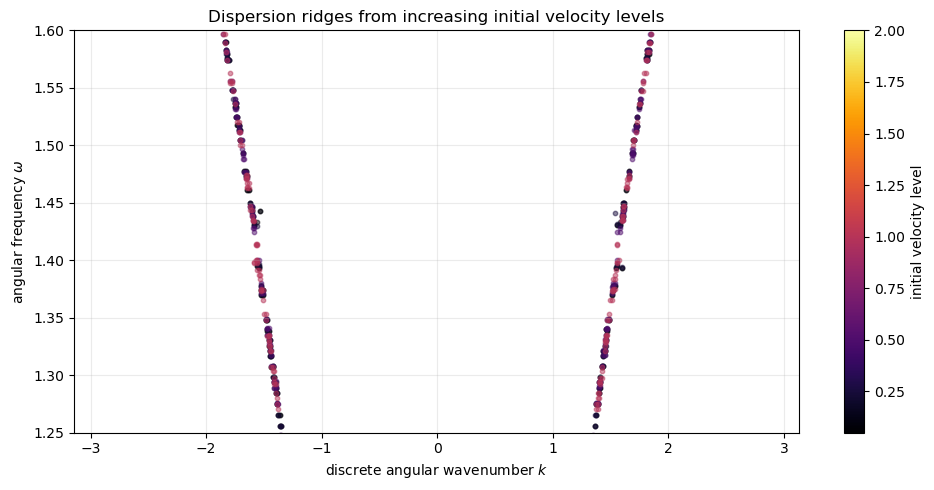

In [24]:
# Plot the multi-level dispersion ridges. Higher initial velocity levels are drawn in lighter colors.
cmap = plt.cm.inferno
norm = Normalize(vmin=float(np.min(velocity_levels)), vmax=float(np.max(velocity_levels))+1)

fig, ax = plt.subplots(figsize=(10, 5))

for case in ridge_cases:
    velocity_level = case["velocity_level"]
    omega_vals = case["omega_vals_masked"]
    k_vals_case = case["k_vals"]
    top_k_idx = case["top_k_idx"]

    color = cmap(norm(velocity_level))
    for rank in range(top_k_idx.shape[1]):
        ax.scatter(
            k_vals_case[top_k_idx[:, rank]],
            omega_vals,
            s=10,
            alpha=0.5,
            color=color,
            edgecolors=color,
        )

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="initial velocity level")

ax.set_xlabel("discrete angular wavenumber $k$")
ax.set_ylabel("angular frequency $\\omega$")
ax.set_title("Dispersion ridges from increasing initial velocity levels")
ax.set_xlim(ridge_cases[0]["k_vals"][0], ridge_cases[0]["k_vals"][-1])
ax.set_ylim(1.25, 1.6)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

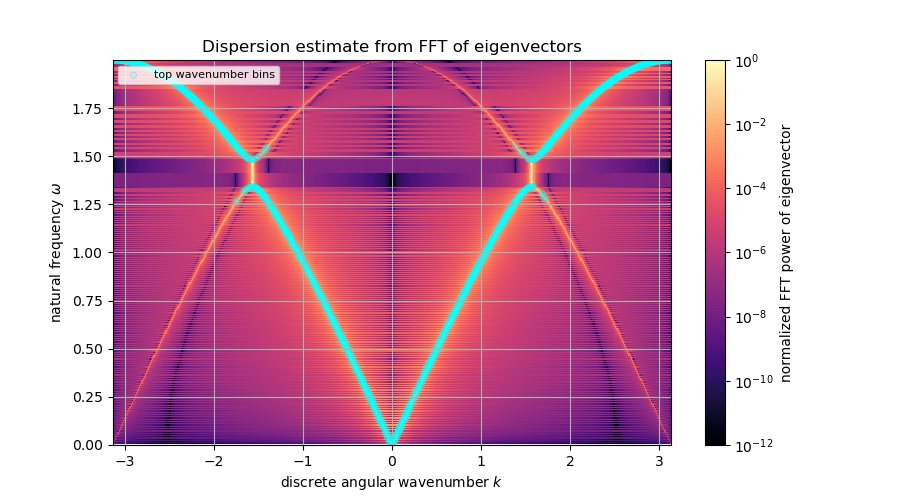

In [ ]:
# Eigenvector-based dispersion analysis, same style as before.
# This uses the mode shapes from the generalized eigenproblem and shows that a single mode can
# contribute energy to multiple wavenumber bins in the FFT visualization.
from matplotlib.colors import LogNorm

mode_fft = np.fft.fftshift(np.fft.fft(modes, axis=0), axes=0)
mode_power = np.abs(mode_fft) ** 2
mode_power /= np.sum(mode_power, axis=0, keepdims=True) + 1e-15

k_vals_mode = 2.0 * np.pi * np.fft.fftshift(np.fft.fftfreq(N, d=1.0))

fig, ax = plt.subplots(figsize=(9, 5))
positive_power = mode_power[mode_power > 0]
norm = LogNorm(vmin=max(positive_power.min(), 1e-12), vmax=1.0)
pcm = ax.pcolormesh(k_vals_mode, omega_n, mode_power.T, shading="auto", cmap="magma", norm=norm)
fig.colorbar(pcm, ax=ax, label="normalized FFT power of eigenvector")

# Show the strongest few wavenumber bins for each mode instead of collapsing to one peak.
top_k_idx = np.argsort(mode_power, axis=0)[-3:, :]
for rank in range(top_k_idx.shape[0]):
    ax.scatter(
        k_vals_mode[top_k_idx[rank]],
        omega_n,
        s=16,
        alpha=0.4,
        facecolors="none",
        edgecolors="cyan",
        label="top wavenumber bins" if rank == 0 else None,
    )

ax.set_xlabel("discrete angular wavenumber $k$")
ax.set_ylabel("natural frequency $\omega$")
ax.set_title("Dispersion estimate from FFT of eigenvectors")
ax.set_xlim(k_vals_mode[0], k_vals_mode[-1])
ax.set_ylim(0, np.max(omega_n))
ax.legend(loc="upper left", fontsize=8)
plt.show()


In [ ]:
# Chirp FRF amplitude sweep in parallel; FFT is computed inside each worker to keep memory low
from joblib import Parallel, delayed
import os
import uuid
from pathlib import Path

results_dir = Path('results_chirp_amp')
results_dir.mkdir(exist_ok=True)

# Sweep settings
amp_sweep_values = np.linspace(0.01, 3, 16)
f0 = 0.01
f1 = 3.0
points_per_period = 200
n_periods_total = 500
dt = 1.0 / (points_per_period * f1)
t_end = n_periods_total / f1 * 2
t_eval = np.arange(0.0, t_end + dt, dt)

def simulate_chirp_case(amplitude):
    def chirp_force(t):
        return amplitude * chirp(t, f0=f0, f1=f1, t1=t_end, method='linear')

    def external_force_chirp(t):
        force = np.zeros(N)
        force[forced_mass] = chirp_force(t)
        return force

    def rhs_chirp(t, y):
        u = y[:N]
        v = y[N:]
        damping = damping_force(v)
        forces = spring_forces(u)
        a = (forces[1:] - forces[:-1] + damping[1:] - damping[:-1] + external_force_chirp(t)) / m
        return np.concatenate([v, a])

    sol = solve_ivp(
        rhs_chirp,
        (t_eval[0], t_eval[-1]),
        y0,
        method='RK45',
        t_eval=t_eval,
        # max_step=dt,
        rtol=1e-9,
        atol=1e-10,
    )
    if not sol.success:
        raise RuntimeError(sol.message)

    u = sol.y[N:, :].copy()
    v = sol.y[:N, :].copy()
    force_ts = np.asarray([chirp_force(tt) for tt in sol.t])

    freqs = np.fft.rfftfreq(u.shape[1], d=dt)
    u_fft = np.fft.rfft(u, axis=1)
    v_fft = np.fft.rfft(v, axis=1)
    force_fft = np.fft.rfft(force_ts)

    fname = results_dir / f"chirp_frf_A{int(round(1000 * amplitude))}_{uuid.uuid4().hex}.npz"
    np.savez_compressed(
        fname,
        t=sol.t,
        force=force_ts,
        u_fft=u_fft,
        v_fft=v_fft,
        force_fft=force_fft,
        freqs=freqs,
        amplitude=amplitude,
        f0=f0,
        f1=f1,
    )

    return {
        'amplitude': float(amplitude),
        'file': str(fname),
    }

n_workers = min(len(amp_sweep_values), max(1, os.cpu_count() or 1), 30)
results_meta_chirp = Parallel(n_jobs=n_workers, verbose=12)(delayed(simulate_chirp_case)(a) for a in amp_sweep_values)

def load_chirp_results(results_meta=None, results_dir=str(results_dir)):
    if results_meta is None:
        return [LazyNPZ(p) for p in sorted(Path(results_dir).glob('chirp_frf_A*.npz'))]
    return [LazyNPZ(m['file'], amplitude=float(m['amplitude'])) for m in results_meta]

results_chirp = load_chirp_results(results_meta_chirp)
print(f'Prepared {len(results_chirp)} chirp FRF result handle(s) using {n_workers} worker(s).')


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   1 tasks      | elapsed:  2.1min
[Parallel(n_jobs=16)]: Done   3 out of  16 | elapsed:  2.2min remaining:  9.4min
[Parallel(n_jobs=16)]: Done   5 out of  16 | elapsed:  2.2min remaining:  4.8min
[Parallel(n_jobs=16)]: Done   7 out of  16 | elapsed:  2.2min remaining:  2.8min
[Parallel(n_jobs=16)]: Done   9 out of  16 | elapsed:  2.2min remaining:  1.7min
[Parallel(n_jobs=16)]: Done  11 out of  16 | elapsed:  2.2min remaining:  1.0min
[Parallel(n_jobs=16)]: Done  13 out of  16 | elapsed:  2.2min remaining:   30.8s


Prepared 16 chirp FRF result handle(s) using 16 worker(s).


[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:  2.2min finished


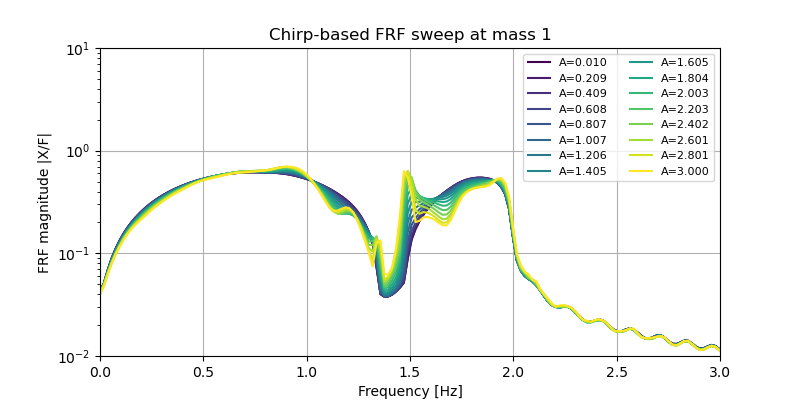

In [ ]:
%matplotlib widget
# Quick overview plot with lighter colors for higher amplitudes
fig = plt.figure(figsize=(8, 4))
amplitudes = np.array([r['amplitude'] for r in results_chirp], dtype=float)
norm = plt.Normalize(amplitudes.min(), amplitudes.max())
cmap = plt.cm.viridis
for r in sorted(results_chirp, key=lambda item: item['amplitude']):
    color = cmap(norm(r['amplitude']))
    plt.semilogy(r['freqs']*2*np.pi, np.mean(np.abs(r['u_fft'][20:,:]), axis=0)/np.abs(r['force_fft']), color=color, label=f"A={r['amplitude']:.3f}")
plt.xlabel('Frequency [Hz]')
plt.ylabel('FRF magnitude |X/F|')
plt.title(f'Chirp-based FRF sweep at mass {forced_mass}')
plt.grid(True)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
# sm.set_array([])
# fig.colorbar(sm,  label='Amplitude')
plt.legend(ncol=2, fontsize=8)
plt.xlim(0, 3)
plt.ylim(1e-2, 10)

plt.show()

In [ ]:
stop
single_run = simulate_chain()
t = single_run["t"]
y = single_run["y"]
u = single_run["u"]
v = single_run["v"]
energy = single_run["energy"]

print(f"Integrated {N} masses from t=0 to t={t[-1]:.2f} using solve_ivp with {len(t)} saved times.")
print(f"Forced mass index: {forced_mass}")
print(f"Relative mechanical energy change: {(energy[-1] - energy[0]) / energy[0]:.3e}")


NameError: name 'stop' is not defined

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(
    u.T,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], 0, N - 1],
    cmap="RdBu_r",
)
ax.set_xlabel("time")
ax.set_ylabel("mass index")
ax.set_title("Displacement field $u_n(t)$")
fig.colorbar(im, ax=ax, label="displacement")
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5))
for mass_idx in history_mass_indices:
    ax.plot(t, u[:, mass_idx], label=f"mass {mass_idx}")
ax.set_xlabel("time")
ax.set_ylabel("displacement")
ax.set_title("Mass displacement time histories")
ax.legend(ncol=3)
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5))
for frac in [0.0, 0.25, 0.5, 0.75, 1.0]:
    idx = int(frac * (len(t) - 1))
    ax.plot(np.arange(N), u[idx], label=f"t={t[idx]:.1f}")
ax.set_xlabel("mass index")
ax.set_ylabel("displacement")
ax.set_title("Displacement snapshots")
ax.legend(ncol=3)
plt.show()


# Amplitude and frequency sweep studies

The cells below run periodic forced-response sweeps. Frequencies are angular frequencies because the forcing is written as $F(t)=A\sin(\omega t+\phi)$.


In [ ]:
# Sweep response curves
fig, axs = plt.subplots(1, 2, figsize=(11, 4))

axs[0].plot([r["amplitude"] for r in results_amp_chain], [r["peak_u"] for r in results_amp_chain], "o-", label="peak")
axs[0].plot([r["amplitude"] for r in results_amp_chain], [r["rms_u"] for r in results_amp_chain], "s-", label="rms")
axs[0].set_xlabel("force amplitude")
axs[0].set_ylabel(f"mass {sweep_observed_mass} displacement")
axs[0].set_title(f"Amplitude sweep, omega={amp_sweep_frequency:.3f}")
axs[0].legend()

axs[1].plot([r["frequency"] for r in results_freq_chain], [r["peak_u"] for r in results_freq_chain], "o-", label="peak")
axs[1].plot([r["frequency"] for r in results_freq_chain], [r["rms_u"] for r in results_freq_chain], "s-", label="rms")
axs[1].set_xlabel("drive frequency omega")
axs[1].set_ylabel(f"mass {sweep_observed_mass} displacement")
axs[1].set_title(f"Frequency sweep, A={freq_sweep_amplitude:.3f}")
axs[1].legend()

fig.tight_layout()
plt.show()


In [ ]:
# Phase portraits for selected amplitude and frequency cases
amp_case_index = -1
freq_case_index = len(results_freq_chain) // 2
phase_portrait_periods = 40

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, result, title in [
    (axs[0], results_amp_chain[amp_case_index], "amplitude sweep case"),
    (axs[1], results_freq_chain[freq_case_index], "frequency sweep case"),
]:
    keep = phase_portrait_periods * sweep_points_per_period
    for j, mass_idx in enumerate(result["observed_indices"]):
        ax.plot(result["u_obs"][-keep:, j], result["v_obs"][-keep:, j], lw=0.9, label=f"mass {mass_idx}")
    ax.set_xlabel("displacement")
    ax.set_ylabel("velocity")
    ax.set_title(f"{title}: A={result['amplitude']:.3f}, omega={result['frequency']:.3f}")
    ax.legend(ncol=2, fontsize=8)

fig.tight_layout()
plt.show()


In [ ]:
# Poincare maps / bifurcation-style diagrams for the observed mass
fig, axs = plt.subplots(1, 2, figsize=(11, 4))

for r in results_amp_chain:
    obs_col = list(r["observed_indices"]).index(r["observed_mass"])
    vals = r["u_poincare"][obs_col]
    axs[0].plot(np.full_like(vals, r["amplitude"]), vals, ".", ms=3, alpha=0.65)
axs[0].set_xlabel("force amplitude")
axs[0].set_ylabel(f"mass {sweep_observed_mass} stroboscopic displacement")
axs[0].set_title("Amplitude-sweep Poincare map")

for r in results_freq_chain:
    obs_col = list(r["observed_indices"]).index(r["observed_mass"])
    vals = r["u_poincare"][obs_col]
    axs[1].plot(np.full_like(vals, r["frequency"]), vals, ".", ms=3, alpha=0.65)
axs[1].set_xlabel("drive frequency omega")
axs[1].set_ylabel(f"mass {sweep_observed_mass} stroboscopic displacement")
axs[1].set_title("Frequency-sweep Poincare map")

fig.tight_layout()
plt.show()
